In [1]:
import pandas as pd

# === Load and preprocess ===
df = pd.read_csv("indiv_spearman_duplicates_grouped_norepeat_Specificity_model_cnn1.csv")

# Fill down missing edge names
df['Feature'] = df['Feature'].fillna(method='ffill')

# Preserve original feature order
original_order = df['Feature'].dropna().unique()
df['Feature'] = pd.Categorical(df['Feature'], categories=original_order, ordered=True)

# Group and filter
results = []

for feature in original_order:
    group = df[df['Feature'] == feature]
    spearman_values = group["Spearman Correlation"].dropna()

    if len(spearman_values) >= 2:
        q1 = spearman_values.quantile(0.25)
        q3 = spearman_values.quantile(0.75)
        median = spearman_values.median()

        if q1 > 0:
            results.append((feature, round(q1, 3), round(q3, 3), round(median, 3)))

# Output as DataFrame with original order preserved
iqr_df = pd.DataFrame(results, columns=["Feature", "Q1", "Q3", "Median Spearman Correlation"])
iqr_df["Feature"] = pd.Categorical(iqr_df["Feature"], categories=original_order, ordered=True)
iqr_df = iqr_df.sort_values("Feature")

# Display and save
print(iqr_df)
iqr_df.to_csv("indiv_features_with_positive_IQR_Specificity_model_cnn1.csv", index=False)


    Feature     Q1     Q3  Median Spearman Correlation
0   Pos22_A  0.766  0.766                        0.766
1   Pos22_T  0.772  0.773                        0.773
2   Pos23_A  0.763  0.763                        0.763
3   Pos24_A  0.732  0.739                        0.738
4   Pos24_T  0.750  0.789                        0.782
5   Pos25_A  0.637  0.734                        0.713
6   Pos25_T  0.786  0.787                        0.787
7   Pos26_A  0.452  0.637                        0.590
8   Pos26_C  0.360  0.706                        0.613
9   Pos26_T  0.657  0.772                        0.752
10  Pos27_A  0.728  0.756                        0.749
11  Pos27_T  0.621  0.778                        0.753
12  Pos28_A  0.769  0.769                        0.769
13  Pos28_T  0.739  0.771                        0.762
14  Pos29_A  0.745  0.745                        0.745
15  Pos29_C  0.116  0.514                        0.195
16  Pos29_T  0.742  0.782                        0.772
17  Pos30_

/var/folders/8p/2p_212ld2qvgjsycxk_lmmg00000gn/T/ipykernel_36372/1177157296.py:7: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['Feature'] = df['Feature'].fillna(method='ffill')


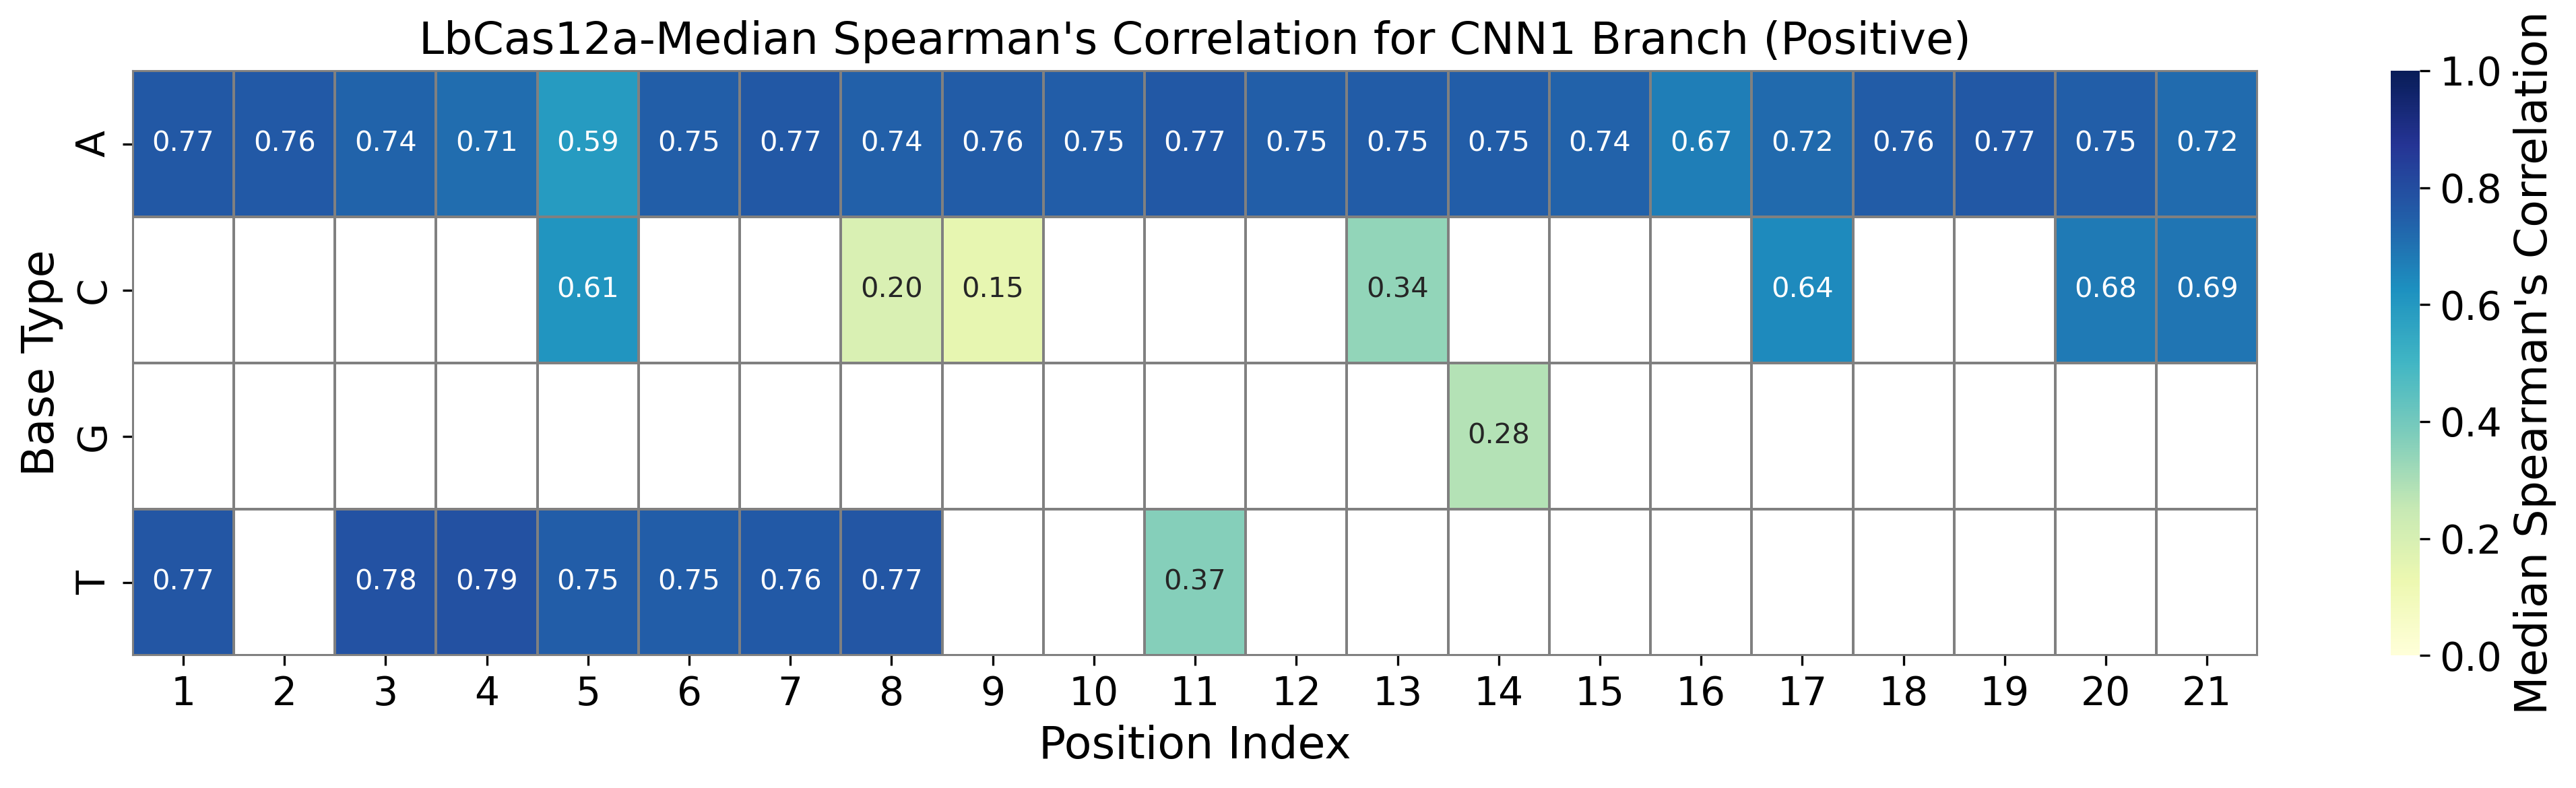

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load processed feature list
iqr_df = pd.read_csv("indiv_features_with_positive_IQR_Specificity_model_cnn1.csv")
iqr_df[['Pos', 'Base']] = iqr_df['Feature'].str.extract(r'Pos(\d+)_(\w)')
iqr_df['Pos'] = iqr_df['Pos'].astype(int)

# Pivot to heatmap format
heatmap_data = iqr_df.pivot(index="Base", columns="Pos", values="Median Spearman Correlation")

# Ensure all expected position indices are shown (e.g., 1–max observed)
full_pos_range = range(iqr_df['Pos'].min(), iqr_df['Pos'].max() + 1)
heatmap_data = heatmap_data.reindex(columns=full_pos_range)

mask = heatmap_data.isna()

# Plot heatmap
fig, ax = plt.subplots(figsize=(14, 4), dpi=300)
hm = sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    vmin=0,
    vmax=1,
    cbar_kws={"label": "Median Spearman Correlation"},
    linewidths=0.5,
    linecolor='gray',
    square=False,
    mask=mask,
    ax=ax
)

# Force x-axis labels to start from 1
n_pos = heatmap_data.shape[1]
ax.set_xticks(np.arange(n_pos) + 0.5)
ax.set_xticklabels(range(1, n_pos + 1), fontsize=14)


# === Fix for missing bottom and right borders ===
# Turn on all spines (border lines)
for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_color('gray')


# Set custom font sizes
ax.set_xlabel("Position Index", fontsize=16)
ax.set_ylabel("Base Type", fontsize=16)
ax.set_title("LbCas12a-Median Spearman's Correlation for CNN1 Branch (Positive)", fontsize=16)

# Set tick label sizes
ax.tick_params(axis='x', labelsize=14)
ax.tick_params(axis='y', labelsize=14)

# === Adjust colorbar font sizes ===
cbar = hm.collections[0].colorbar
cbar.ax.tick_params(labelsize=14)  # Colorbar tick labels
cbar.set_label("Median Spearman's Correlation", fontsize=16)  # Colorbar title

plt.tight_layout()
plt.show()
